# DABN13 - Assignment 2

This assignment consists of two parts. Part 1 covers principal component regression (PCR), while Part 2 covers regularization methods. The two parts are independent of each other and are based on different data sets.

---------------------------------------------------------------------------------------
---------------------------------------------------------------------------------------

# <span style="color:blue"> Part 1: PCR</span>

We continue with the problem of forecasting market return that we illustrated in Lecture 5. In order to train the implementation of PCR, we will  replicate our previous results with a slight twist. More specifically, we will choose tuning parameters via cross-validation. Additionally, the training sets used for model evaluation are defined differently. While the example in Lecture 5 defined an expanding window of training sets with fixed starting period, we are going to use a rolling window that moves both the start and end date of the training set.

The data for this lab is provided by two csv files. 
The file *sorted_portfolios100.csv* contains the monthly returns of 100 equally weighted portfolios sorted by size and the book-to-market ratio. The data is taken from Kenneth French's data library and missing values have been imputed. The time period covered is January 1960 until December 2009
The file *twelve_month_returns.csv* contains 12-month returns on a value-weighted market portfolio. This series takes moving 12-month sums of returns of the U.S. market factor, as provided on Kenneth French's data library. The entry in row $t$ of the dataset corresponds to the market returns over the months $t+1$ until $t+12$. Accordingly, the first observed value in our sample is the 12-month return over the period February 1960 - January 1961. The last observation covers the period January-December 2010.

To begin with, we import both your outcome as well as the 100 predictors into Python using the code below. You might be required to modify the file path.


In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from os import chdir
import os

#chdir('?') Adjust directory here
os.chdir('c:\\Users\\Vicente\\Desktop\\Lund - MSc Economics\\ML - From a Regression perspective\\ml-course\\data') # Change working directory here
mkt_ret_12m = pd.read_csv("twelve_month_returns.csv").iloc[:,1:]  # this is our y-variable
portfolios  = pd.read_csv("sorted_portfolios100.csv").iloc[:,1:]  # these are our x-variables


mkt_ret_12m_train = mkt_ret_12m.iloc[:540, :]
portfolios_train  = portfolios.iloc[:540, :]  

mkt_ret_12m_test = mkt_ret_12m.iloc[540:, :]
portfolios_test  = portfolios.iloc[540:, :]

## 1a) Correlation matrix

**TASKS**

1. Compute a Pearson correlation matrix for all variables in the `portfolios_train` dataset using the `corr()` method (see the [documentation](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.corr.html)). The code for generating the heatmap from the correlation matrix has already been provided, do not modify it.
3. Write a short interpretation of the correlation heatmap and store it in the string variable `your_interpretation_of_correlation_matrix`. Focus on the overall correlation pattern: Are many or few variables correlated with each other? Are the correlations generally strong or weak?

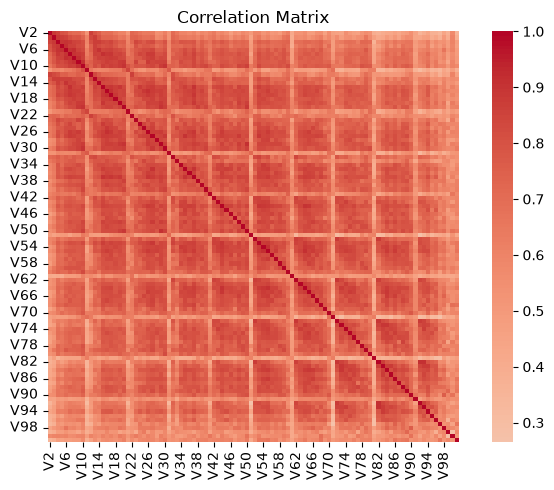

In [3]:
# 1.
corr = portfolios_train.corr('pearson')

# do not change the next 11 lines
plt.figure(figsize = (7, 5))
sns.heatmap(
    corr,
    cmap = "coolwarm",
    center = 0,
    annot = False,
    square = True
)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

# 2. 
your_interpretation_of_correlation_matrix = """ The columns of our portfolios matrix is highly correlated to each other, so potential multicollinearity. The correlations are overall strong, which make sense due to the protfolios sharing the same market factors. """

## 1b) Setting up a PCR pipeline in `sklearn`

Principal component regression is not available in scikit-learn as a distinctive learning algorithm. This is no problem because it is the combination of three simple components:

1. standardizing inputs,
2. obtaining $k$ principal components from the inputs,
3. running a linear regression of the output on the $k$ principal components (and a constant).

All three operations above are implemented in sklearn. In order to put them together, we will use the very convenient `Pipeline()` functionality (see the [documentation](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html)).
Pipelines allow us to specify a custom sequence of actions. An existing pipeline can be fit, similar to the specification of a regression model. If we do that, all steps of the pipeline are executed in their specified order.

We will create and fit a pipeline for PCR. First, we need to specify the three actions mentioned above individually. This can be done by using the `StandardScaler()`, `PCA()` and `LinearRegression()` functions from several `sklearn` modules. I have already written code below to import these functions.

*Hint*: In the ISLP book (2023 Python edition), you can find inspiration in section 6.5.3. We won't do the exact same thing, but it can be of help when learning how to specify pipelines, how to use `PCA()` etc.

**TASKS**
1. Create 3 objects, `standardizer_1b`, `pca_1b` and `lm_1b` which specify input standardization, PCA **without specifying the number of components**, a linear regression model, respectively. 

2. Specify the 3 steps of our pipeline and give them suitable names. Save the resulting object as `pcr_pipe`. I have written code that clones this Pipeline multiple times. Later in Part 1, we will need several pipelines with largely the same structure. Rather than making you repeatedly write the same pipeline specification, I've written code that clones your `pcr_pipe` multiple times.

4. Use `set_params()` on `pcr_pipe_1b` to specify the number of components to be **5**. 

5. Apply the `fit()`-method to `pcr_pipe_1b` to execute the entire pipeline. Do this using `mkt_ret_12m_train`and `portfolios_train` as your output and inputs, respectively. Save the fitted pipeline as `pcr_pipe_fit_1b`. Note that this is now fitted using 5 principal components.



In [5]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.base import clone

# 1.
standardizer_1b = StandardScaler()
pca_1b = PCA()
lm_1b = LinearRegression()  

# 2. 
pcr_pipe = Pipeline(steps = [('scaler', standardizer_1b), ('pca', pca_1b), ('lm', lm_1b)])

# Do not change the 5 lines below (see the note above)
pcr_pipe_1b = clone(pcr_pipe)
pcr_pipe_1c_no_lrm = clone(pcr_pipe[:-1])
pcr_pipe_1c = clone(pcr_pipe)
pcr_pipe_1d = clone(pcr_pipe)
pcr_pipe_1e_no_pca = clone(Pipeline([pcr_pipe.steps[0], pcr_pipe.steps[2]]))

# 3.
pcr_pipe_1b.set_params(pca__n_components = 5)

# 4.
pcr_pipe_fit_1b  = pcr_pipe_1b.fit(X = portfolios_train, y = mkt_ret_12m_train)  # we will use this pipeline later

## 1c) Cumulative explained variance

In the previous task, the number of principal components we used was an arbitrary choice. A more informed way to choose the number of principal components is to examine the cumulative explained variance, which you will do in this exercise.

In the first code chunk I ask you to not modify things. Here, we standardize the data and fit the PCA algorithm **without** a specific number of components. We do **not** fit a linear regression, because the regression step was removed from the pipeline `pcr_pipe_1c_no_lrm`. Hence, we perform *PCA* and not *PCR*. After the fitting procedure, the code is for plotting the **cumulative explained variance**

**TASKS** 

1. You need to *interpret the plot and suggest an appropriate number of principal components*. Write your answer in the string variable `interpretation_plot_1c`. There is **no single correct answer**; your choice should be motivated based on the features of the plot.

   *HINT*: While it's not in your suggested reading, you can find inspiration on page 514 of the ISLP book (2023 python ed.). The plot shows, for each possible number of principal components, the share of the total variance in the original data that is explained by those components *together*. Use the plot to assess how many components are needed to capture a sufficiently large share of the variance.

2. For `pcr_pipe_1c`, specify `n_components` **as the number you consider reasonable based on the plot**. 

3. Fit `pcr_pipe_1c` to the training data and store as `pcr_pipe_fit_1c`. Note that this pipeline contains the regression step, so we are fitting a linear regression as the last step.

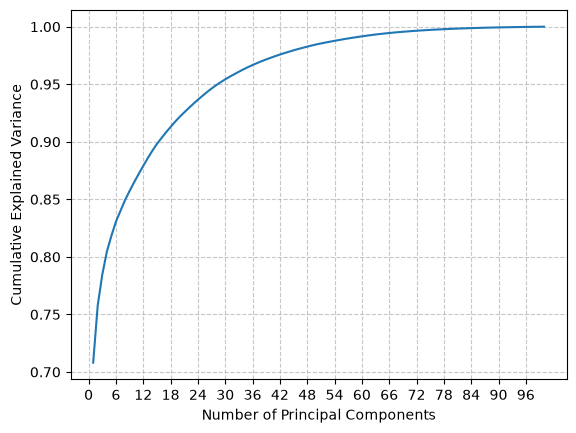

In [6]:
# Do not change any of the lines below
pcr_pipe_1c_no_lrm.fit(portfolios_train)
pca_1c = pcr_pipe_1c_no_lrm.named_steps['pca']

n_components = np.arange(1, len(pca_1c.explained_variance_ratio_) + 1)
plt.plot(n_components, np.cumsum(pca_1c.explained_variance_ratio_))
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True, linestyle = "--", alpha = 0.7)
plt.xticks(np.arange(0, len(pca_1c.explained_variance_ratio_) + 1, 6))
plt.show()

# 1.
interpretation_plot_1c = """ I have chosen to use 6 principal components, the reason for this is that by introducing one component, we are basically explaining 71 of the variance, so the 5 additionals are added to capture the second structure, up to around 83 percent which seems a reasonable share to retain """
# 2.
pcr_pipe_1c.set_params(pca__n_components = 6)

# 3
pcr_pipe_fit_1c  = pcr_pipe_1c.fit(X = portfolios_train, y = mkt_ret_12m_train)  # we will use this pipeline later

## *1d) Model tuning*

Another more informed way to choose the number of principal components is to use `sklearn`for model tuning. The tuning parameter of PCR is the number of principal components to use. 

**TASKS**

1. Create a parameter grid for the number of principal components. Use 3, 4, 10, 15, 20, 30, and 35 as candidate values and store the dictionary as `parameter_grid_1d`. (*Hint*: You can check ISLP section 6.5.3 for inspiration on how to define a grid).
   
3. Use `TimeSeriesSplit()` to create the cross-validation splitting strategy `cv_splits_1d`, with these properties:
     - Training folds should always consist of at most 90 data points.
     - The test fold following the training folds should only contain 1 data point.
     - We want a total of 450 splits, so that the training fold window moves through the entire length of `mkt_ret_12m_train` and `portfolios_train`.
     - No gap between training and test folds.
     - Please check the  `TimeSeriesSplit()`-[documentation](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.TimeSeriesSplit.html#sklearn.model_selection.TimeSeriesSplit) to figure out how to set the function inputs.
       
  
4. Use the `GridSearchCV()` function in the `model_selection` module of Scikit-learn to specify the setup for model tuning. To be more specific, we want the following:
     - tune the model pipeline `pcr_pipe_1d`.
     - use the grid of tuning parameter values stored in `parameter_grid_1d`,
     - cross-validation is conducted based on the splits defined in `cv_splits_1d`,
     - performance should be evaluated using the negative root mean square error.
     - the parameter `refit` must be set to its default value ('True'), so do **not** change it.
     - Look up the `GridSearchCV()`-[documentation](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html) to figure out how to set the function arguments correctly.
     - Save the resulting setup for model tuning as `pcr_tune_1d`.
       
5. Run the tuning procedure by applying the `fit()`-method to `pcr_tune_1d`. Use `portfolios_train` and `mkt_ret_12m_train` as inputs and output, respectively. `pcr_tune_1d` now contains cross-validation results, the optimal tuning parameter value, the learned model with this value and more.

6. Use the `GridSearchCV()` documentation to find out how to identify the optimal tuning parameter value. In the string variable `optimal_number_components`, report the value and explain which code you used to find it.
   
7. Identify the fitted pipeline corresponding to the optimal tuning parameter value and save it as `pcr_pipe_tuned_1d`. (*Hint*: You need to use one of the Attributes in GridSearchCV)

In [11]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.model_selection import GridSearchCV

# 1. 
parameter_grid_1d = {'pca__n_components': [3, 4, 10, 15, 20, 30, 35]}

# 2.
cv_splits_1d     = TimeSeriesSplit(n_splits = 450, test_size= 1, gap=0, max_train_size= 90)

# 3.
pcr_tune_1d = GridSearchCV(pcr_pipe_1d,
                           param_grid=parameter_grid_1d, 
                           cv=cv_splits_1d, 
                           scoring= 'neg_root_mean_squared_error', 
                           n_jobs = -1)

# 4.
pcr_tune_1d.fit(portfolios_train, mkt_ret_12m_train) 

# 5.
optimal_number_components = print(f""" The optimal number of principal components is {pcr_tune_1d.best_params_['pca__n_components']}.
I found it using pcr_tune_1d.best_params_, which returns the parameter
dictionary of the configuration with the best mean cross-validated score. """)

# 6.
pcr_pipe_tuned_1d = pcr_tune_1d.best_estimator_ # we will use this pipeline later

 The optimal number of principal components is 30.
I found it using pcr_tune_1d.best_params_, which returns the parameter
dictionary of the configuration with the best mean cross-validated score. 


## *1e) Test set performance*

So far, we have only used the **training** data set, which consists of the first 540 observations. Once a model has been fitted to the training data, we can use it to generate predictions for new observations using the predict() method.

To evaluate how well our fitted models perform on new data, we compare their predictions with the observed outcomes in the **test** data set. The test data have been kept separate throughout the lab and will now be used as a hold-out sample for evaluating predictive performance. We will evaluate the models using mean squared error (MSE) and R².

I have already fitted a pipeline for a simple linear regression model, called `lm_pipe_fit_1e`. This is a model without any PCA application.

I have also provided a function `evaluate_models`for generating predictions on the test set and evaluating their performance. 

**TASKS**

1. In the a dictionary called `pipelines_1e` you should enter the fitted pipelines from Tasks 1b)–1d). The linear regression pipeline has already been added to the dictionary as an example.
   
3. Create a dictionary containing the two performance metrics, MSE and R². Save it as `metrics_1e`.
   
4. In the string variable `interpretation_function`, write a brief description of what is happening inside the `evaluate_models` function.
   
5. Run the code to get a printed table. In the string variable `comparison_models_1e`, I want you to do the following:
   - briefly interpret the performance metrics
   - compare the PCR models with the standard linear regression model. Do any of the PCR models perform better? If so, why might this be?
   - compare the predictive performance of the different PCR models and discuss why their performance may differ.

     *Hint*: Consider the number of principal components used by the different PCR models and how this number was selected in 1c) versus 1d). What criterion was used in each case, and why might these criteria lead to different test-set performance? Also consider whether your findings from task in 1a) can help explain some results.

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

# Do not change the lines below
lm_pipe_fit_1e = pcr_pipe_1e_no_pca.fit(X = portfolios_train, y = mkt_ret_12m_train)

def evaluate_models(pipelines_dict, metrics_dict, X_test, y_test):
    results = []

    for name, pipeline in pipelines_dict.items():
        y_pred = pipeline.predict(X_test) 

        model_results = {"Model": name}

        for metric_name, metric_function in metrics_dict.items():
            model_results[metric_name] = metric_function(y_test, y_pred)

        results.append(model_results)

    results = (
        pd.DataFrame(results)
          .round(3)
    )

    return results
    
# 1.
pipelines_1e = {
    "Linear Regression": lm_pipe_fit_1e,
    "PCR (5 comp., arbitrary)": pcr_pipe_fit_1b,
    "PCR (6 comp., explained variance)": pcr_pipe_fit_1c,
    "PCR (M comp., CV-tuned)": pcr_pipe_tuned_1d
}

# 2.
metrics_1e = {
    "MSE": mean_squared_error,
    "R²": r2_score
}


results_1e = evaluate_models(
    pipelines_dict = pipelines_1e,
    metrics_dict = metrics_1e,
    X_test = portfolios_test,
    y_test = mkt_ret_12m_test
)

print(results_1e)

# 3. 
interpretation_function = """ he function takes a dictionary of fitted pipelines and a dictionary of
performance metrics. It loops over each pipeline, applies predict() to the
test inputs X_test to generate predictions, and then evaluates every metric
in the metrics dictionary by comparing those predictions to the observed
outcomes y_test. The results for each model are collected in a dictionary
and all models are combined into a pandas DataFrame, rounded to three
decimals. Because X_test and y_test were held out from both the fitting and
the tuning of all models, the resulting figures estimate performance on new
data rather than training error. """

# 4.
comparison_models_1e = """
The CV-tuned PCR model performs best on the test set, with the lowest MSE
(0.048) and the only positive R² (0.189). Unregularised linear regression
performs worst by a wide margin (MSE 0.093, R² -0.554). Since R² is computed
as 1 - MSE/Var(y_test), a negative value means the model predicts worse than
simply using the mean of the test outcomes: the linear regression is 55%
worse than that constant benchmark, and the 5- and 6-component PCR models
are approximately at it. Only the CV-tuned model improves on it, explaining
about 19% of the out-of-sample variance.

PCR versus linear regression: the gap is large. Unregularised regression
estimates 101 coefficients from 540 observations, while each PCR model
estimates only M+1. Task 1a showed that the 100 portfolios are strongly
correlated with one another, and task 1c showed that a single principal
component accounts for 70.8% of their total variance. The data therefore
varies very little along most directions of the input space. Coefficient
variance in a given direction is sigma^2/d_i^2, so the directions with
little variation are precisely those whose coefficients are estimated with
very large variance. The linear regression fits all of them and transfers
that instability into its predictions, while PCR discards them, accepting
some bias in exchange for a large reduction in variance. Moving from the
linear regression to even an arbitrarily chosen 5 components cuts the MSE
by 34%.

Differences among the PCR models: all three share the same pipeline and
differ only in M, so they occupy different points on the bias-variance
trade-off. Models 1b (M=5) and 1c (M=6) perform almost identically, which is
unsurprising given that they are adjacent values and the sixth component adds
only 1.2 percentage points of explained variance. The CV-tuned model (M=[..])
improves on both by a further 20%. The explanation lies in the selection
criterion rather than in the models themselves. Cumulative explained variance
is computed from the inputs alone and never consults the market return, so it
can identify where the predictors vary but not whether that variation is
informative about the outcome. Cross-validation selects directly on
out-of-sample forecast error and therefore retains components for their
predictive value. The results indicate that components beyond the sixth carry
predictive content despite contributing little additional input variance,
which is exactly the limitation of the unsupervised criterion used in 1c.

A caveat on the absolute figures: the test period runs from January 2005, so
the twelve-month outcomes cover the 2008 financial crisis, a market episode
with no comparable precedent in the 1960-2004 training sample. The input
distribution in the evaluation window therefore differs from the one the
models were trained on, which plausibly contributes to the weak absolute
performance of all four models. The ranking across models is more informative
here than the absolute level of MSE or R².
"""

                               Model    MSE     R²
0                  Linear Regression  0.093 -0.554
1           PCR (5 comp., arbitrary)  0.061 -0.020
2  PCR (6 comp., explained variance)  0.060 -0.015
3            PCR (M comp., CV-tuned)  0.049  0.180


---------------------------------------------------------------------------------------
--------------------------------------------------------------------------------------

# <span style="color:blue"> Part 2: Regularization Methods</span>

Air carriers regularly update their destination network and a necessary condition for adding a new flight connection to the existing network is that flights on this route are profitable. In addition to costs, profitability is determined by the price at which competitors could cater to the demand for flight transportation between two locations. A data-driven way of determining this would be on the basis of a supervised learning algorithm that has been trained on the fares for existing flight connections and which leverages information about route-specific characteristics. The dataset that we are using in this lab contains such information for more than 600 flight connections between different American cities. More specifically, we have information on the number of required stops, the market concentration on a particular route, Holiday destination status and a number of other characteristics that are detailed on [p.7 in the `mlba` library documentation](https://github.com/gedeck/mlba/blob/main/mlba_2.0.0.pdf). In the following, we will train and tune different supervised learning models that predict the average fare for a flight.


## 2a) Data 

`sklearn` requires us to provide output and inputs separately as data frames containing numerical variables that can be directly put into a cost minimization problem. Provide that by conducting the following steps:

**TASKS**
1. Save the output variable *FARE* as pandas series `y_2a`.

2. The other variables in `Airfares` are the predictors. Save them as a Pandas dataframe `X_2a`. Then, use the `get_dummies()` function in Pandas to turn categorical variables into category dummies. Ensure that the first category of every categorical variable is dropped.

3. We currently have 13 predictors. To create a high-dimensional problem, we want to expand the set of predictors by adding all pairwise interaction terms. Use `PolynomialFeatures()` to specify the transformer `poly2_spec_2a`. Include interactions between pairs of original inputs, but **do not include squared terms or a constant term**. Use `fit_transform()` to apply the transformer to `X_2a`. This gives us a total of 91 predictor variables.

   
8. Use the  `train_test_split()` function in the model selection module of `sklearn` to split `X_2a` and `y_2a` into training and test data sets. Use 70% of the observations for training.



In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures

Airfares = pd.read_csv("Airfares.csv") # Adjust file path if necessary
Airfares = Airfares.drop(columns = ["S_CODE", "S_CITY", "E_CODE", "E_CITY"])

# 1.
y_2a = Airfares['FARE']

# 2. 
X_2a = Airfares.drop(columns = ['FARE'])
X_2a = pd.get_dummies(X_2a)

# 3. 
poly2_spec_2a = PolynomialFeatures(include_bias=False, degree=2, interaction_only=True)
X_2a = poly2_spec_2a.fit_transform(X_2a)

# 4.
X_train_2a, X_test_2a, y_train_2a, y_test_2a = train_test_split(X_2a, y_2a, test_size=0.3, random_state=42)


## 2b) Ridge and Lasso: Coefficient paths

We will first examine how the coefficients estimated by Ridge and Lasso change with the strength of regularization.

`lambda_grid` contains 100 candidate values for the regularization parameter $\lambda$. Do not change this.


**TASKS**

1. Use `StandardScaler()` to standardize the `X_train_2a`. Save as `X_train_2b`.
   
5. In the for-loop, one `Ridge` estimator is fitted for each candidate value of $\lambda$ in `lambda_grid`. Specify the sklearn parameter corresponding to $\lambda$, and the attribute containing the fitted coefficient vector. *Hint*: Check the [documentation](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Ridge.html), particularly the **Parameters** section and the **Attributes** section.

11. Repeat Task 3 using `Lasso`. If you receive a convergence warning, check the `Lasso` [documentation](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Lasso.html) and increase the maximum number of iterations until the estimator converges.
   
12. The provided plotting code will use these coefficient vectors to plot the Ridge and Lasso coefficient paths. Run the code. Then interpret the two coefficient paths **separately**. Store your Ridge interpretation in `interpretation_Ridge_path` and your Lasso interpretation in `interpretation_Lasso_path`. For each method, describe how increasing $\lambda$ affects the estimated coefficients and note any characteristic differences in how the coefficients approach zero.

*Do not compare the amount of shrinkage at the same numerical value of $\lambda$ across Ridge and Lasso. The penalty functions differ, so equal numerical values of $\lambda$ do not represent directly comparable amounts of regularization across the two estimators.*


c:\Users\Vicente\Desktop\Lund - MSc Economics\ML - From a Regression perspective\ml-course\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:842: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.493339e+03, tolerance: 2.503e+02
  model = cd_fast.enet_coordinate_descent(
c:\Users\Vicente\Desktop\Lund - MSc Economics\ML - From a Regression perspective\ml-course\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:842: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.077441e+03, tolerance: 2.503e+02
  model = cd_fast.enet_coordinate_descent(
c:\Users\Vicente\Desktop\Lund - MSc Economics\ML - From a Regression perspective\ml-course\.venv\Lib\site-packages\sklearn\linear_model\_coordinat

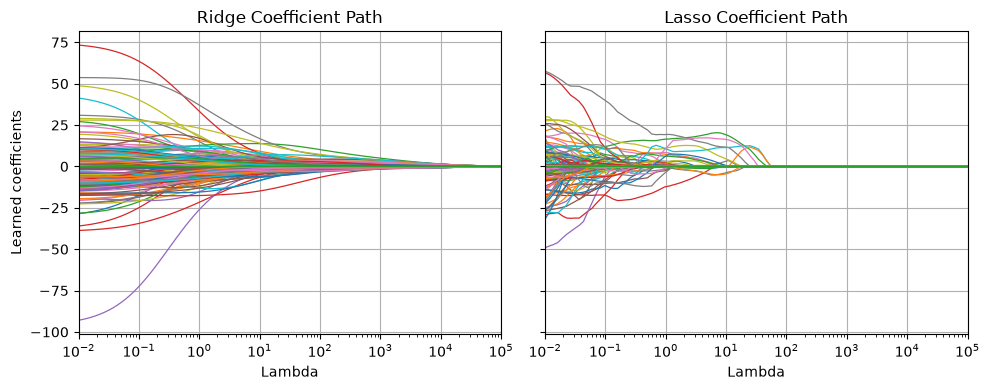

In [15]:
from sklearn.linear_model import (Ridge, Lasso)

lambda_grid = np.logspace(5, -2, 100)

# 1.
X_train_2b = StandardScaler().fit_transform(X_train_2a)

# 2.
coefs_ridge = []
for lambda_candidate in lambda_grid:
    ridge = Ridge(alpha = lambda_candidate).fit(X_train_2b, y_train_2a)
    coefs_ridge.append(ridge.coef_)

# 3. 
coefs_lasso = []
for lambda_candidate in lambda_grid:
    lasso = Lasso(alpha = lambda_candidate, max_iter = 1000).fit(X_train_2b, y_train_2a)
    coefs_lasso.append(lasso.coef_)


# Do not change any of the lines below 
fig, ax = plt.subplots(1, 2, figsize = (10, 4), sharey = True)
for axis, coefs, title in zip(ax,
    [coefs_ridge, coefs_lasso],
    ["Ridge Coefficient Path", "Lasso Coefficient Path"]):
    axis.plot(lambda_grid, coefs, linewidth = 0.9)
    axis.set_xscale("log")
    axis.set_xlim(lambda_grid.min(), lambda_grid.max())
    axis.set_xlabel("Lambda")
    axis.set_title(title)
    axis.grid(True)
ax[0].set_ylabel("Learned coefficients")
plt.tight_layout()
plt.show()


# 4.
interpretation_Ridge_path = """
As lambda increases, all coefficients shrink smoothly and monotonically in
magnitude toward zero, but none of them reaches exactly zero at any point on
the grid. At the smallest lambda values the coefficients are close to their
unpenalised least-squares values and are widely dispersed; as lambda grows
they contract together and the paths converge toward a common value of zero
without ever arriving. The approach is asymptotic: the L2 penalty has
derivative 2*beta, which vanishes as beta approaches zero, so there is never
a finite lambda at which it becomes worthwhile to set a coefficient exactly
to zero. Ridge therefore shrinks but never selects, and every one of the 91
predictors remains in the model at every level of regularisation.
"""

interpretation_Lasso_path = """
As lambda increases, coefficients also shrink, but they reach exactly zero at
finite values of lambda and remain there for all larger lambda. The paths are
piecewise linear rather than smooth, with kinks occurring at the lambda values
where a variable enters or leaves the active set. Variables drop out one at a
time, so the number of nonzero coefficients falls progressively until, at the
largest lambda values, all coefficients are zero. This behaviour follows from
the L1 penalty, whose derivative is +/-1 regardless of how small the
coefficient is: there is a fixed cost to keeping any coefficient nonzero, and
a variable whose contribution to the fit does not cover that cost is set to
exactly zero. Lasso therefore performs variable selection in addition to
shrinkage.
"""


## 2c) Tuning Ridge, Lasso and Elastic Net in one go!

We have now inspected the coefficient paths for Ridge and Lasso regression. However, we still do not know which value of the regularization parameter ($\lambda$) is optimal for prediction. We therefore want to tune these algorithms using K-fold cross-validation. In addition, we will introduce Elastic Net.

In Part 1 (PCR), we tuned one pipeline specification: (Scaler, PCA, Linear regression). Now we want to tune 3 pipeline specifications: (scaler, Ridge), (scaler, Lasso) and (scaler, Elastic Net). Doing this separately would involve a lot of repetition. Fortunately, GridSearchCV allows us to combine the three specifications into a single parameter grid and tune them together, without having to build separate grids or run the procedure separately for each estimator.


**TASKS**

1. In contrast to Part 1 of this assignment, we no longer have time-ordered data. Therefore, we will not use `TimeSeriesSplit()` to partition the training data. Instead, we will use `KFold()`, which works like the splitting strategy you have seen in the lecture slides. Use  `KFold()` to create a **random** partition into five folds. Set the `random_state` to 5 for the sake of replicability. Save the splitting strategy as `cv_splits_2c`.

   
2. Specify a pipeline that standardizes the data as a first step. Name the second step `model` and use Ridge regression as the estimator. Here, Ridge will only be a placeholder and will be overwritten later. Save the pipeline as `pipe_2c`.
    
3. `param_grid_2c` is a *list* containing three *dictionaries*. Each dictionary should specify one estimator and its candidate hyperparameter values. I have already done this for Ridge. Your task is to complete the dictionaries for Lasso and Elastic Net. For Elastic Net, we want to tune two hyperparameters: the regularization strength ($\lambda$) and the mixing ratio. Therefore, the Elastic Net dictionary must contain 3 items (the first being the model).  *For all 3 estimators*: use the candidate values of $\lambda$ stored in `lambda_grid` (which we specified in task 2b). *For Elastic Net*: use the candidate values of the mixing ratio stored in `elnet_mixing_ratio_grid`.

   
5. Complete the `GridSearchCV()` by setting the splitting strategy to `cv_splits_2c`, and use negative mean squared error as the scoring measure. Do not change the code that has already been provided. Save the resulting GridSearchCV object as `grid_search_2c`.
   
6. Fit `grid_search_2c` to the training data.

7. Extract the cross-validation results from `grid_search_2c` and convert them to a pandas DataFrame. Save the resulting DataFrame as `results_tuning_2c`. The code below this task tidies the DataFrame and adds the model names (don't change it).

8. Look at the Dataframe being printed. In the string variable `best_ridge_lambda_analysis`, do the following:

   - Report the value of $\lambda$ that was selected as optimal by the cross-validation for Ridge regression. 
   - Return to the Ridge coefficient path in Task 2b. Using the optimal value of $\lambda$, describe the extent to which the coefficients are shrunk toward zero relative to a linear regression model without regularization. (The plot is very zoomed out, so you only need to eyeball it, not exact values)

     
9. Look at the DataFrame again. In the string variable `interpretation_CV_results`, explain what the following columns represent: split0_test_score, split1_test_score, split2_test_score, split3_test_score,	split4_test_score,	mean_test_score,	std_test_score. What does each of these values reflect in the cross-validation procedure?



In [ ]:
from sklearn.model_selection import KFold
from sklearn.linear_model import ElasticNet


# 1.
cv_splits_2c = KFold(n_splits = 5, shuffle = True, random_state = 5)

# 2.
pipe_2c = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Ridge())
])

# 3.
elnet_mixing_ratio_grid = np.linspace(0.0001, 1, 10)

param_grid_2c = [
    {
        'model': [Ridge()],
        'model__alpha': lambda_grid    },
    {
        'model': [Lasso(max_iter = 100000)],
        'model__alpha': lambda_grid    },
    {
        'model': [ElasticNet(max_iter = 100000)],
        'model__alpha': lambda_grid,
        'model__l1_ratio': elnet_mixing_ratio_grid    }
]

# 4.
grid_search_2c = GridSearchCV(estimator = pipe_2c,
                           param_grid = param_grid_2c,
                           cv = cv_splits_2c,
                           scoring = 'neg_mean_squared_error',
                           refit = False,
                           n_jobs = -1)

# 5.
grid_search_2c.fit(X_train_2a, y_train_2a)

# 6.
results_tuning_2c = pd.DataFrame(grid_search_2c.cv_results_)

# Do not change the lines below
results_tuning_2c.insert(
    0, 
    'model', 
    results_tuning_2c['param_model'].apply(lambda x: type(x).__name__))
best_models_2c = results_tuning_2c.loc[
    results_tuning_2c.groupby('model')['mean_test_score'].idxmax()
].reset_index(drop=True)

display(best_models_2c)


# 7. 
best_ridge_lambda_analysis = """
Cross-validation selected alpha = 10.97 as the optimal regularisation strength
for Ridge regression, with a mean cross-validated score of -999.13 (negative
MSE).

Locating this value on the Ridge coefficient path from task 2b: the horizontal
axis runs on a log scale from 10^-2 to 10^5, so alpha = 10.97 sits just right
of 10^1. By that point the coefficients have already been shrunk very
substantially relative to the unpenalised fit. At the left edge of the plot
the coefficients are widely dispersed, ranging from roughly -90 to +75, and
the bulk of the contraction occurs between alpha = 10^-1 and alpha = 10^1.
At the selected value the paths have collapsed into a narrow band of roughly
-5 to +5, so the largest coefficients retain only a small fraction of their
least-squares magnitude. The paths continue to converge towards zero
thereafter and are visually indistinguishable from zero from about alpha =
10^3 onward.

The selected model is therefore strongly regularised: cross-validation
preferred coefficients an order of magnitude smaller than those of
unpenalised least squares. This is consistent with the test-set results,
where the unregularised linear regression performed markedly worse than all
three regularised models.

One further feature of the Ridge path is worth noting. Several coefficients
are not monotone in alpha: the largest positive path rises from about 40 to
75 before falling, and the largest negative path rises from about -90 toward
zero in a non-monotone fashion. This reflects the fact that Ridge shrinks
along the principal directions of the design rather than shrinking each
coefficient independently, so individual coefficients — which are
combinations of those directions — need not decrease monotonically even
though the overall coefficient vector does.

Note that this value is not comparable to the alpha of 0.305 selected for
Lasso. The two sklearn objectives are scaled differently — Lasso divides the
residual sum of squares by 2n while Ridge does not — so equal numerical values
of alpha do not represent equal amounts of regularisation across the two
estimators.
"""

# 8. 
Interpretation_CV_results = """
Each of split0_test_score through split4_test_score is the score obtained on
one of the five validation folds: the model was fitted on the other four
folds and evaluated on the held-out one, so each value is an out-of-sample
score from a model that never saw those observations. mean_test_score is the
average of those five values and is the cross-validation estimate of
predictive performance for that hyperparameter combination; it is the
quantity used to rank candidates. std_test_score is the standard deviation
across the five folds and measures how stable that estimate is: a large value
means performance varied considerably depending on which observations were
held out, so the mean should be treated with more caution. Scores are
negative because sklearn reports negative MSE, so higher is better.
"""

,model,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model,param_model__alpha,param_model__l1_ratio,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,ElasticNet,0.008206,0.001483,0.001343,0.000762,ElasticNet(max_iter=100000),0.305386,1.0,"{'model': ElasticNet(max_iter=100000), 'model_...",-1142.241416,-1103.390469,-1026.757192,-864.231205,-703.936486,-968.111354,162.874490,1
1,Lasso,0.013449,0.002781,0.001971,0.000402,Lasso(max_iter=100000),0.305386,NaN,"{'model': Lasso(max_iter=100000), 'model__alph...",-1142.241416,-1103.390469,-1026.757192,-864.231205,-703.936486,-968.111354,162.874490,1
2,Ridge,0.004192,0.000768,0.001142,0.000276,Ridge(),10.974988,NaN,"{'model': Ridge(), 'model__alpha': 10.97498765...",-1170.930157,-1103.665040,-1037.776668,-923.105966,-760.150675,-999.125701,144.794479,121


## 2d) Prediction performance evaluation

We have now found the optimal hyperparameter values for Ridge, Lasso, and Elastic Net. Because we tuned the three models together using GridSearchCV with refit=False, no estimator is refitted or stored as the best fitted model. To evaluate the performance of all three models on the untouched test data, we therefore need to fit their pipelines to the training data again using the optimal hyperparameter values. Since this involves repetitive code, I have already provided it below. I have also fitted a simple linear regression without regularization to the training data, which we will use for comparison.

Your tasks are to complete the evaluation of the four fitted pipelines.

**TASKS**
1. We want to evaluate the predictive performance using mean squared error. Specify this in the dictionary `metrics_2d`.
   
3. We will reuse the `evaluate_models` function from the PCA task. I have already specified `pipelines_2d`. Complete the remaining arguments to the function.

   
3. A table showing the MSE on the test set will be printed. Which of the four models performs best? Write your conclusion, including some discussion of the margin between the best-performing model and the remaining models, in the string variable `conclusion_2d`.

   
7. Why do you think one candidate performs better than another? In particular, compare the simple linear regression with the regularized models. Discuss the results in the string variable `discussion_2d`.



In [ ]:
from sklearn.base import clone

# Do not change the code below
pipelines_2d = {}

for _, row in best_models_2c.iterrows():
    pipe = clone(pipe_2c)
    pipe.set_params(**row['params'])
    pipe.fit(X_train_2a, y_train_2a)
    pipelines_2d[row['model']] = pipe

lm_pipe_2d = clone(pipe_2c).set_params(model = LinearRegression())
lm_pipe_2d.fit(X_train_2a, y_train_2a)
pipelines_2d['LinearRegression'] = lm_pipe_2d


# 1.
metrics_2d = {"MSE": mean_squared_error}

# 2.
results_2d = evaluate_models(
    pipelines_dict = pipelines_2d,
    metrics_dict = metrics_2d,
    X_test = X_test_2a,
    y_test = y_test_2a
)
print(results_2d)


# 3. 
conclusion_2d = """
Lasso and Elastic Net achieve the lowest test MSE (932.25), followed closely
by Ridge (942.13), while the unregularised linear regression is clearly worst
(1139.61). The margins are very uneven. All three regularised models improve
on the linear regression by roughly 17-18%, which in fare units corresponds to
a root mean squared error of about $30.5 instead of $33.8. By contrast, the
differences among the three regularised models are small: Ridge is about 1%
worse than Lasso, and Elastic Net is identical to Lasso. The identity is not a
coincidence: cross-validation selected a mixing ratio of l1_ratio = 1.0 for
Elastic Net, at which the Elastic Net objective reduces exactly to the Lasso
objective, so the two are the same estimator with the same alpha (0.305).
The gap between Ridge and Lasso should also be treated cautiously, since the
standard deviation of the cross-validation scores across folds was roughly
145-163, far larger than the 31-point difference between their mean CV scores.
The meaningful conclusion is therefore that regularisation helps substantially,
while the choice among the three regularised methods does not.
"""



# 4.
discussion_2d = """
The large gap between the linear regression and the regularised models follows
from the dimensionality constructed in task 2a. Starting from 13 predictors,
the pairwise interaction expansion produced 91 inputs, which are estimated from
roughly 420 training observations. The unregularised regression spends 92
degrees of freedom on that sample and fits every direction of the input space,
including directions in which the data barely varies. Coefficient variance in
such a direction is sigma^2/d_i^2, so these poorly determined directions
contribute large, unstable coefficients that carry little information, and that
instability is transferred into the predictions on new data. The problem is
aggravated by the structure of the expanded design: each interaction term x_i*x_j
is correlated with its own parent variables by construction, so the columns are
strongly collinear and many d_i are small. The regularised models accept a
small amount of bias, by shrinking coefficients toward zero, in exchange for a
large reduction in variance, and the test results show that this trade is
clearly worthwhile here.

That Lasso performs marginally better than Ridge is consistent with the
interaction expansion producing many terms that carry no real predictive
content: Lasso sets those coefficients exactly to zero and removes them, while
Ridge retains all 91 predictors in shrunken form. The fact that Elastic Net
converged on l1_ratio = 1.0 points the same way, since it indicates that adding
an L2 component to the penalty did not improve cross-validated performance.
However, given how small the Ridge-Lasso margin is relative to the variation
across cross-validation folds, this evidence is suggestive rather than
conclusive.
"""

              Model       MSE
0        ElasticNet   932.249
1             Lasso   932.249
2             Ridge   942.126
3  LinearRegression  1139.613


# <span style="color:blue"> AI statement</span>

Please type 'yes' in the string `we_have_used_AI` below if you have used AI in any sense for this assignment. Otherwise, type 'no'. 

A 'yes' or 'no' is enough, you do **not** need to describe which AI tool you used, what you used it for, etc.

In [ ]:
we_have_used_AI = " hell yes "